In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# Load dataset
dataset = pd.read_csv('quarter_car_dataset.csv')

# Feature matrix (Input)
X = dataset[['Mass', 'DampingCoefficient', 'SpringCoefficient', 'Time']]

# Target matrix (Output)
Y = dataset[['Displacement', 'Velocity']]

In [3]:
dataset.head

<bound method NDFrame.head of            Time  Mass  DampingCoefficient  SpringCoefficient  Displacement  \
0       0.00000   200                1000              15000  1.000000e-01   
1       0.01001   200                1000              15000  9.963067e-02   
2       0.02002   200                1000              15000  9.854953e-02   
3       0.03003   200                1000              15000  9.679728e-02   
4       0.04004   200                1000              15000  9.441931e-02   
...         ...   ...                 ...                ...           ...   
74995   9.95996   400                3000              25000 -6.445788e-11   
74996   9.96997   400                3000              25000 -5.932700e-11   
74997   9.97998   400                3000              25000 -5.421190e-11   
74998   9.98999   400                3000              25000 -4.913803e-11   
74999  10.00000   400                3000              25000 -4.412722e-11   

           Velocity  
0      0.00

In [4]:
X.head


<bound method NDFrame.head of        Mass  DampingCoefficient  SpringCoefficient      Time
0       200                1000              15000   0.00000
1       200                1000              15000   0.01001
2       200                1000              15000   0.02002
3       200                1000              15000   0.03003
4       200                1000              15000   0.04004
...     ...                 ...                ...       ...
74995   400                3000              25000   9.95996
74996   400                3000              25000   9.96997
74997   400                3000              25000   9.97998
74998   400                3000              25000   9.98999
74999   400                3000              25000  10.00000

[75000 rows x 4 columns]>

In [5]:
Y.head

<bound method NDFrame.head of        Displacement      Velocity
0      1.000000e-01  0.000000e+00
1      9.963067e-02 -7.313560e-02
2      9.854953e-02 -1.421651e-01
3      9.679728e-02 -2.067916e-01
4      9.441931e-02 -2.667602e-01
...             ...           ...
74995 -6.445788e-11  5.137170e-10
74996 -5.932700e-11  5.139193e-10
74997 -5.421190e-11  5.110151e-10
74998 -4.913803e-11  5.052306e-10
74999 -4.412722e-11  4.967924e-10

[75000 rows x 2 columns]>

In [6]:
from sklearn.model_selection import train_test_split

# Split dataset into training (80%) and test sets (20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize scalers
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

# Fit scalers on training data and transform
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, Y_train_scaled)

# Make predictions
Y_pred_scaled = linear_model.predict(X_test_scaled)

# Unscale predictions
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)

# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
r_squared = r2_score(Y_test, Y_pred)
print(f'MSE for Linear Regression: {mse}')
print(f'R-squared: {r_squared}')


MSE for Linear Regression: 0.00256727471918412
R-squared: 0.03180636866962466


In [9]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, Y_train_scaled)

# Make predictions
Y_pred_scaled_rf = rf_model.predict(X_test_scaled)

# Unscale predictions
Y_pred_rf = scaler_Y.inverse_transform(Y_pred_scaled_rf)

# Evaluate the model
mse_rf = mean_squared_error(Y_test, Y_pred_rf)
r_squared_rf = r2_score(Y_test, Y_pred_rf)
print(f'MSE for Random Forest: {mse_rf}')
print(f'R-squared: {r_squared_rf}')


MSE for Random Forest: 6.641015705028375e-06
R-squared: 0.9979248901164404


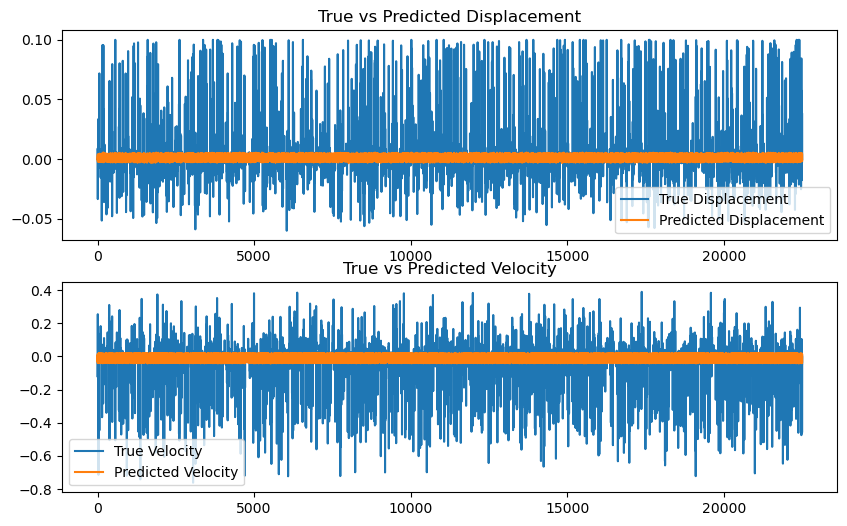

In [17]:
import matplotlib.pyplot as plt

# Plot for Displacement
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(Y_test['Displacement'].values, label='True Displacement')
plt.plot(Y_pred[:, 0], label='Predicted Displacement')
plt.title('True vs Predicted Displacement')
plt.legend()

# Plot for Velocity
plt.subplot(2, 1, 2)
plt.plot(Y_test['Velocity'].values, label='True Velocity')
plt.plot(Y_pred[:, 1], label='Predicted Velocity')
plt.title('True vs Predicted Velocity')
plt.legend()

# plt.tight_layout()
plt.show()
